# Temporal difference prediction and control

In this notebook, you will implement temporal difference approaches to prediction and control described in [Sutton and Barto's book, Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html). We will use the grid ```World``` class from the previous lectures. 

### Install dependencies

In [114]:
! pip install numpy pandas

'pip' is not recognized as an internal or external command,
operable program or batch file.


### Imports

In [115]:
import numpy as np
import random
import sys          # We use sys to get the max value of a float
import pandas as pd # We only use pandas for displaying tables nicely
pd.options.display.float_format = '{:,.3f}'.format

### ```World``` class and globals

The ```World``` is a grid represented as a two-dimensional array of characters where each character can represent free space, an obstacle, or a terminal. Each non-obstacle cell is associated with a reward that an agent gets for moving to that cell (can be 0). The size of the world is _width_ $\times$ _height_ characters.

A _state_ is a tuple $(x,y)$.

An empty world is created in the ```__init__``` method. Obstacles, rewards and terminals can then be added with ```add_obstacle``` and ```add_reward```.

To calculate the next state of an agent (that is, an agent is in some state $s = (x,y)$ and performs and action, $a$), ```get_next_state()```should be called.

In [116]:
# Globals:
ACTIONS = ("up", "down", "left", "right") 

# Rewards, terminals and obstacles are characters:
REWARDS = {" ": 0, ".": 0.1, "+": 10, "-": -10}
TERMINALS = ("+", "-") # Note a terminal should also have a reward assigned
OBSTACLES = ("#")

# Discount factor
gamma = 1

# The probability of a random move:
rand_move_probability = 0

class World:  
  def __init__(self, width, height):
    self.width = width
    self.height = height
    # Create an empty world where the agent can move to all cells
    self.grid = np.full((width, height), ' ', dtype='U1')
  
  def add_obstacle(self, start_x, start_y, end_x=None, end_y=None):
    """
    Create an obstacle in either a single cell or rectangle.
    """
    if end_x == None: end_x = start_x
    if end_y == None: end_y = start_y
    
    self.grid[start_x:end_x + 1, start_y:end_y + 1] = OBSTACLES[0]

  def add_reward(self, x, y, reward):
    assert reward in REWARDS, f"{reward} not in {REWARDS}"
    self.grid[x, y] = reward

  def add_terminal(self, x, y, terminal):
    assert terminal in TERMINALS, f"{terminal} not in {TERMINALS}"
    self.grid[x, y] = terminal

  def is_obstacle(self, x, y):
    if x < 0 or x >= self.width or y < 0 or y >= self.height:
      return True
    else:
      return self.grid[x ,y] in OBSTACLES 

  def is_terminal(self, x, y):
    return self.grid[x ,y] in TERMINALS

  def get_reward(self, x, y):
    """ 
    Return the reward associated with a given location
    """ 
    return REWARDS[self.grid[x, y]]

  def get_next_state(self, current_state, action):
    """
    Get the next state given a current state and an action. The outcome can be
    stochastic  where rand_move_probability determines the probability of 
    ignoring the action and performing a random move.
    """    
    assert action in ACTIONS, f"Unknown acion {action} must be one of {ACTIONS}"
    
    x, y = current_state 
    
    # If our current state is a terminal, there is no next state
    if self.grid[x, y] in TERMINALS:
      return None

    # Check of a random action should be performed:
    if np.random.rand() < rand_move_probability:
      action = np.random.choice(ACTIONS)

    if action == "up":      y -= 1
    elif action == "down":  y += 1
    elif action == "left":  x -= 1
    elif action == "right": x += 1

    # If the next state is an obstacle, stay in the current state
    return (x, y) if not self.is_obstacle(x, y) else current_state


## A simple world and a simple policy

In [117]:
world = World(2, 3)

# Since we only focus on episodic tasks, we must have a terminal state that the 
# agent eventually reaches
world.add_terminal(1, 2, "+")

def equiprobable_random_policy(x, y):
  return { k:1/len(ACTIONS) for k in ACTIONS }

# print(world.grid.T)
display(pd.DataFrame(world.grid.T))

,0,1
0,,
1,,
2,,+


## Exercise: TD prediction

You should implement TD prediction for estimating $V≈v_\pi$. See page 120 of [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html).


To implement TD prediction, the agent has to interact with the world for a certain number of episodes. However, unlike in the Monte Carlo case, we do not rely on complete sample runs, but instead update estimates (for prediction and control) and the policy (for control only) each time step in an episode.


Below, you can see the code for running an episode, with a TODO where you have to add your code for prediction. Also, play with the parameters ```alpha``` and ```EPISODES```, you will typically need a lot more than 10 episodes for an agent to learn anything.

In [118]:
# Global variable to keep track of current estimates
V_TD = np.full((world.width, world.height), 0.0)

# Our step size / learing rate 
alpha = 0.05 

# Discount factor
gamma = 0.9

# Episodes to run 
EPISODES = 1000

def TD_prediction_run_episode(world, policy, start_state):
    current_state = start_state
    while not world.is_terminal(*current_state):
        # Get the possible actions and their probabilities that our policy says 
        # that the agent should perform in the current state: 
        possible_actions = policy(*current_state)

        # Pick a weighted random action: 
        action = random.choices(population=list(possible_actions.keys()), 
                                weights=possible_actions.values(), k=1)  
        
        # Get the next state from the world
        next_state = world.get_next_state(current_state, action[0])
        
        # Get the reward for performing the action
        reward = world.get_reward(*next_state)

        ###TODO: =============================================================
        ###TODO: Substitute the next line of code with your own
        ###TODO: =============================================================

        V_TD[*current_state] += alpha * (reward + gamma * V_TD[*next_state] - V_TD[*current_state])

        print(f"Current state (S) = {current_state}, next_state S' = {next_state}, reward = {reward}")

        # Move the agent to the new state
        current_state = next_state


for episode in range(EPISODES):
    # print(f"Episode {episode + 1 }/{EPISODES}:")
    TD_prediction_run_episode(world, equiprobable_random_policy, (0, 0))

display(pd.DataFrame(V_TD.T))

Current state (S) = (0, 0), next_state S' = (0, 1), reward = 0
Current state (S) = (0, 1), next_state S' = (0, 0), reward = 0
Current state (S) = (0, 0), next_state S' = (1, 0), reward = 0
Current state (S) = (1, 0), next_state S' = (1, 0), reward = 0
Current state (S) = (1, 0), next_state S' = (0, 0), reward = 0
Current state (S) = (0, 0), next_state S' = (0, 1), reward = 0
Current state (S) = (0, 1), next_state S' = (0, 1), reward = 0
Current state (S) = (0, 1), next_state S' = (0, 0), reward = 0
Current state (S) = (0, 0), next_state S' = (1, 0), reward = 0
Current state (S) = (1, 0), next_state S' = (1, 1), reward = 0
Current state (S) = (1, 1), next_state S' = (0, 1), reward = 0
Current state (S) = (0, 1), next_state S' = (1, 1), reward = 0
Current state (S) = (1, 1), next_state S' = (1, 0), reward = 0
Current state (S) = (1, 0), next_state S' = (0, 0), reward = 0
Current state (S) = (0, 0), next_state S' = (0, 0), reward = 0
Current state (S) = (0, 0), next_state S' = (0, 1), rew

,0,1
0,3.738,4.290
1,4.895,6.522
2,6.974,0.000


In [119]:
def q_visualizer(world : World, q : np.ndarray) -> None:
    new_q = np.full((world.width, world.height), "", dtype=object)
    action_symbols = {
        'up': '↑',
        'down': '↓', 
        'left': '←',
        'right': '→'
    }
    for x in range(world.width):
        for y in range(world.height):
            if world.is_terminal(x, y):
                new_q[x, y] = '+'
            elif world.is_obstacle(x, y):
                new_q[x, y] = '#'
            else:
                new_q[x, y] = action_symbols[ACTIONS[np.argmax(q[x, y, :])]]

    print("Best action at each state (arrows show direction):")
    display(pd.DataFrame(new_q.T))

## Exercise: SARSA

Implement and test SARSA with an $\epsilon$-greedy policy. See page 130 of [Introduction to Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html) on different worlds. Make sure that it is easy to show a learnt policy (most probable action in each state). 


In [ ]:
def sarsa_prediction(world, start_state, alpha=0.5, gamma=0.9, epsilon=0.1, episodes=1000):
    Q_table = np.full((world.width, world.height, len(ACTIONS)), 0.0) # Q_table[x, y, a_idx]

    policy = lambda state : np.argmax(Q_table[*state, :]) \
                            if random.random() >= epsilon \
                            else random.randint(0, len(ACTIONS)-1)
    
    for _ in range(episodes):
        current_state = start_state
        next_state = None
        action_idx = policy(current_state)

        while not world.is_terminal(*current_state):
            next_state = world.get_next_state(current_state, ACTIONS[action_idx])
            reward = world.get_reward(*next_state)
            next_action_idx = policy(next_state)

            Q_current = Q_table[*current_state, action_idx] # Q(S, A)
            Q_next = Q_table[*next_state, next_action_idx]  # Q(S', A')
            Q_table[*current_state, action_idx] += alpha * (reward + gamma * Q_next - Q_current)

            current_state = next_state
            action_idx = next_action_idx

    return Q_table

In [121]:
sarsa_world = World(10, 7)
sarsa_world.add_terminal(7, 3, "+")

display(pd.DataFrame(sarsa_world.grid.T))
q = sarsa_prediction(sarsa_world, (0, 0), episodes=10000)
q_visualizer(sarsa_world, q)

,0,1,2,3,4,5,6,7,8,9
0,,,,,,,,,,
1,,,,,,,,,,
2,,,,,,,,,,
3,,,,,,,,+,,
4,,,,,,,,,,
5,,,,,,,,,,
6,,,,,,,,,,


Best action at each state (arrows show direction):


,0,1,2,3,4,5,6,7,8,9
0,→,→,→,↓,↓,↓,↓,←,↓,←
1,→,→,→,→,→,↓,↓,←,←,↑
2,↑,↑,←,→,→,→,↓,↓,←,↑
3,↑,↑,↑,↑,↑,↑,→,+,↑,↑
4,↑,↑,↑,↑,↑,↑,↑,↑,↑,↑
5,↑,↑,↑,↑,↑,↑,↑,↑,↑,↑
6,↑,↑,↑,↑,↑,↑,↑,↑,↑,↑


## Exercise: Windy Gridworld

Implement the Windy Gridworld (Example 6.5 on page 130 in the book) and test your SARSA implementation on the Windy Gridworld, first with the four actions (```up, down, left, right```) that move the agent in the cardinal directions, and then with King's moves as described in Exercise 6.9. How long does it take to learn a good policy for different values of $\alpha$ and $\epsilon$?

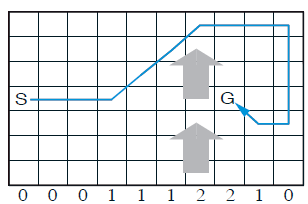

In [122]:
class WindyWorld(World):
    def __init__(self, width, height, wind_strength):
        super().__init__(width, height)
        self.wind_strength = wind_strength # array dict like {x: strength}
    
    def get_next_state(self, current_state, action):
        """
        Get the next state given a current state and an action. The outcome can be
        stochastic  where rand_move_probability determines the probability of 
        ignoring the action and performing a random move.
        """    
        assert action in ACTIONS, f"Unknown acion {action} must be one of {ACTIONS}"
        
        x, y = current_state 

        # If our current state is a terminal, there is no next state
        if self.grid[x, y] in TERMINALS:
            return None

        # Check of a random action should be performed:
        if np.random.rand() < rand_move_probability:
            action = np.random.choice(ACTIONS)

        if action == "up":      y -= 1
        elif action == "down":  y += 1
        elif action == "left":  x -= 1
        elif action == "right": x += 1

        if x in self.wind_strength:
            y -= self.wind_strength[x]

        x = max(0, min(x, self.width - 1))
        y = max(0, min(y, self.height - 1))

        # If the next state is an obstacle, stay in the current state
        return (x, y) if not self.is_obstacle(x, y) else current_state

In [124]:
winds = {
    0: 0,
    1: 0,
    2: 0,
    3: 1,
    4: 1,
    5: 1,
    6: 2,
    7: 2,
    8: 1,
    9: 0
}
REWARDS = {" ": -1, ".": 0.1, "+": 10, "-": -10}
windy_gridworld = WindyWorld(10, 7, winds)
windy_gridworld.add_terminal(7, 3, "+")

display(pd.DataFrame(windy_gridworld.grid.T))
q = sarsa_prediction(windy_gridworld, (0, 3), episodes=10000, gamma=1)
q_visualizer(windy_gridworld, q)

,0,1,2,3,4,5,6,7,8,9
0,,,,,,,,,,
1,,,,,,,,,,
2,,,,,,,,,,
3,,,,,,,,+,,
4,,,,,,,,,,
5,,,,,,,,,,
6,,,,,,,,,,


Best action at each state (arrows show direction):


,0,1,2,3,4,5,6,7,8,9
0,→,↓,←,→,→,→,→,→,→,↓
1,→,→,↓,→,→,←,↓,→,→,↓
2,→,→,→,→,↑,→,↑,→,→,↓
3,→,→,→,→,↑,→,↑,+,→,↓
4,→,↓,→,→,→,↑,↑,↑,→,↓
5,→,→,→,→,↑,↑,↑,↑,←,↓
6,↑,→,→,↑,↑,↑,↑,↑,↑,←


In [125]:
# 0 1 2 3 4 5 6 7 8 9
# 0 0 0 1 1 1 2 2 1 0

SARSA WINDY GRIDWORLD TEST SUITE

### TEST 1: Reproduce Example 6.5 ###

Testing with α=0.5, ε=0.1
Episode 10/170 | Steps: 314 | Avg (last 10): 327.4 | Total steps: 3274
Episode 20/170 | Steps: 48 | Avg (last 10): 120.6 | Total steps: 4480
Episode 30/170 | Steps: 28 | Avg (last 10): 62.8 | Total steps: 5108
Episode 40/170 | Steps: 25 | Avg (last 10): 45.0 | Total steps: 5558
Episode 50/170 | Steps: 45 | Avg (last 10): 39.3 | Total steps: 5951
Episode 60/170 | Steps: 46 | Avg (last 10): 46.5 | Total steps: 6416
Episode 70/170 | Steps: 26 | Avg (last 10): 27.7 | Total steps: 6693
Episode 80/170 | Steps: 30 | Avg (last 10): 32.1 | Total steps: 7014
Episode 90/170 | Steps: 30 | Avg (last 10): 27.9 | Total steps: 7293
Episode 100/170 | Steps: 26 | Avg (last 10): 26.6 | Total steps: 7559
Episode 110/170 | Steps: 20 | Avg (last 10): 27.3 | Total steps: 7832
Episode 120/170 | Steps: 29 | Avg (last 10): 27.0 | Total steps: 8102
Episode 130/170 | Steps: 19 | Avg (last 10): 23.5 | Total steps: 83

,0,1,2,3,4,5,6,7,8,9
0,←,→,↓,→,→,→,→,→,→,↓
1,→,→,→,→,→,→,↑,←,→,↓
2,→,→,→,→,→,→,↑,↓,↑,↓
3,→,→,→,→,→,↓,↑,+,→,↓
4,→,→,→,↑,→,↑,↑,↑,↓,↓
5,↓,→,→,→,↑,↑,↑,↑,←,↓
6,←,→,→,↑,↑,↑,↑,↑,↑,←


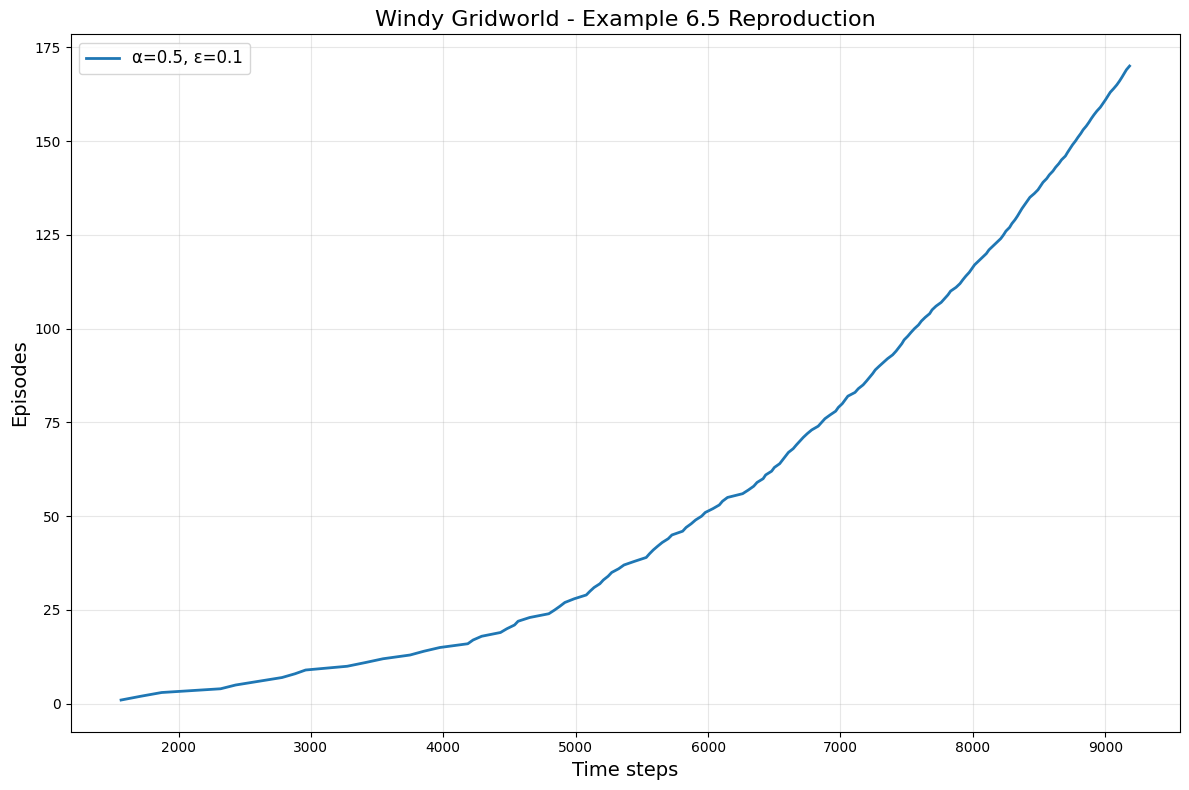

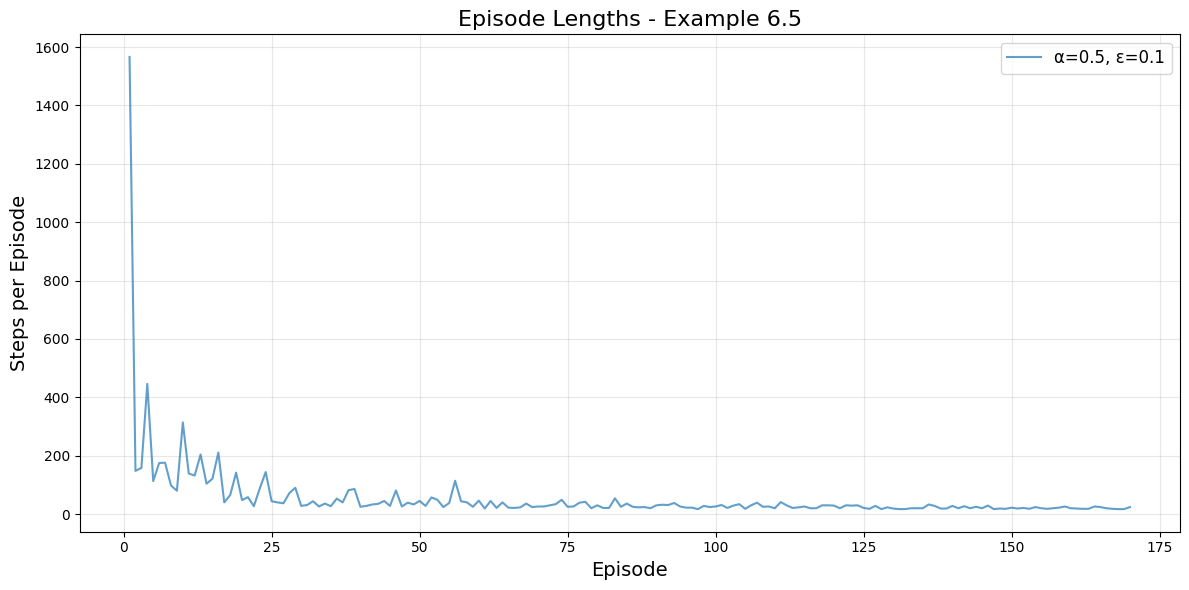


OPTIMAL PATH ANALYSIS
Starting from: (0, 3)
Goal: (7, 3)

Path:
  Step 1: (0, 3) --right--> (1, 3)
  Step 2: (1, 3) --right--> (2, 3)
  Step 3: (2, 3) --right--> (3, 2)
  Step 4: (3, 2) --right--> (4, 1)
  Step 5: (4, 1) --right--> (5, 0)
  Step 6: (5, 0) --right--> (6, 0)
  Step 7: (6, 0) --right--> (7, 0)
  Step 8: (7, 0) --right--> (8, 0)
  Step 9: (8, 0) --right--> (9, 0)
  Step 10: (9, 0) --down--> (9, 1)
  Step 11: (9, 1) --down--> (9, 2)
  Step 12: (9, 2) --down--> (9, 3)
  Step 13: (9, 3) --down--> (9, 4)
  Step 14: (9, 4) --down--> (9, 5)
  Step 15: (9, 5) --down--> (9, 6)
  Step 16: (9, 6) --left--> (8, 5)
  Step 17: (8, 5) --left--> (7, 3)
  Step 18: (7, 3) --up--> (7, 0)
  Step 19: (7, 0) --right--> (8, 0)
  Step 20: (8, 0) --right--> (9, 0)
  Step 21: (9, 0) --down--> (9, 1)
  Step 22: (9, 1) --down--> (9, 2)
  Step 23: (9, 2) --down--> (9, 3)
  Step 24: (9, 3) --down--> (9, 4)
  Step 25: (9, 4) --down--> (9, 5)
  Step 26: (9, 5) --down--> (9, 6)
  Step 27: (9, 6) --left-

,0,1,2,3,4,5,6,7,8,9
0,↓,←,→,↓,→,→,→,→,→,↓
1,→,↓,←,↓,→,→,↓,←,→,↓
2,←,↓,←,→,↓,←,↑,↓,↓,↓
3,↑,↓,↓,←,→,↓,↑,+,→,↓
4,↓,→,←,→,→,↑,↑,↑,↓,↓
5,↓,→,↑,↓,↑,↑,↑,↑,←,↓
6,→,↓,↑,↑,↑,↑,↑,↑,↑,←



Testing with α=0.5, ε=0.1
Episode 10/170 | Steps: 196 | Avg (last 10): 296.1 | Total steps: 2961
Episode 20/170 | Steps: 38 | Avg (last 10): 125.8 | Total steps: 4219
Episode 30/170 | Steps: 38 | Avg (last 10): 79.2 | Total steps: 5011
Episode 40/170 | Steps: 38 | Avg (last 10): 46.3 | Total steps: 5474
Episode 50/170 | Steps: 69 | Avg (last 10): 40.9 | Total steps: 5883
Episode 60/170 | Steps: 56 | Avg (last 10): 35.7 | Total steps: 6240
Episode 70/170 | Steps: 27 | Avg (last 10): 32.4 | Total steps: 6564
Episode 80/170 | Steps: 24 | Avg (last 10): 28.1 | Total steps: 6845
Episode 90/170 | Steps: 29 | Avg (last 10): 32.1 | Total steps: 7166
Episode 100/170 | Steps: 23 | Avg (last 10): 21.8 | Total steps: 7384
Episode 110/170 | Steps: 33 | Avg (last 10): 23.5 | Total steps: 7619
Episode 120/170 | Steps: 22 | Avg (last 10): 23.8 | Total steps: 7857
Episode 130/170 | Steps: 20 | Avg (last 10): 23.4 | Total steps: 8091
Episode 140/170 | Steps: 32 | Avg (last 10): 28.7 | Total steps: 8378

,0,1,2,3,4,5,6,7,8,9
0,←,→,→,→,→,→,→,→,→,↓
1,→,→,↓,→,→,→,→,↓,↓,↓
2,↑,→,↑,→,→,↑,↑,↓,→,↓
3,↓,→,→,→,→,↑,↑,+,→,↓
4,→,→,→,→,→,↑,↑,↑,←,↓
5,→,→,→,→,↑,↑,↑,↑,←,↓
6,→,↓,→,↑,↑,↑,↑,↑,↑,←



Testing with α=0.9, ε=0.1
Episode 10/170 | Steps: 83 | Avg (last 10): 234.5 | Total steps: 2345
Episode 20/170 | Steps: 67 | Avg (last 10): 122.0 | Total steps: 3565
Episode 30/170 | Steps: 55 | Avg (last 10): 73.8 | Total steps: 4303
Episode 40/170 | Steps: 27 | Avg (last 10): 44.1 | Total steps: 4744
Episode 50/170 | Steps: 69 | Avg (last 10): 44.2 | Total steps: 5186
Episode 60/170 | Steps: 29 | Avg (last 10): 39.0 | Total steps: 5576
Episode 70/170 | Steps: 19 | Avg (last 10): 40.9 | Total steps: 5985
Episode 80/170 | Steps: 73 | Avg (last 10): 37.9 | Total steps: 6364
Episode 90/170 | Steps: 25 | Avg (last 10): 30.0 | Total steps: 6664
Episode 100/170 | Steps: 26 | Avg (last 10): 35.0 | Total steps: 7014
Episode 110/170 | Steps: 24 | Avg (last 10): 28.9 | Total steps: 7303
Episode 120/170 | Steps: 32 | Avg (last 10): 29.3 | Total steps: 7596
Episode 130/170 | Steps: 36 | Avg (last 10): 38.2 | Total steps: 7978
Episode 140/170 | Steps: 30 | Avg (last 10): 35.1 | Total steps: 8329


,0,1,2,3,4,5,6,7,8,9
0,←,←,→,→,→,→,↑,→,→,→
1,←,→,→,↑,→,↑,→,↑,→,↓
2,↑,→,↓,↑,←,→,↑,↓,←,↓
3,→,↓,→,→,→,←,↑,+,→,↓
4,→,↓,↑,↓,→,↑,↑,↑,←,↓
5,→,↓,←,→,↑,↑,↑,↑,←,↓
6,→,→,→,↑,↑,↑,↑,↑,↑,←


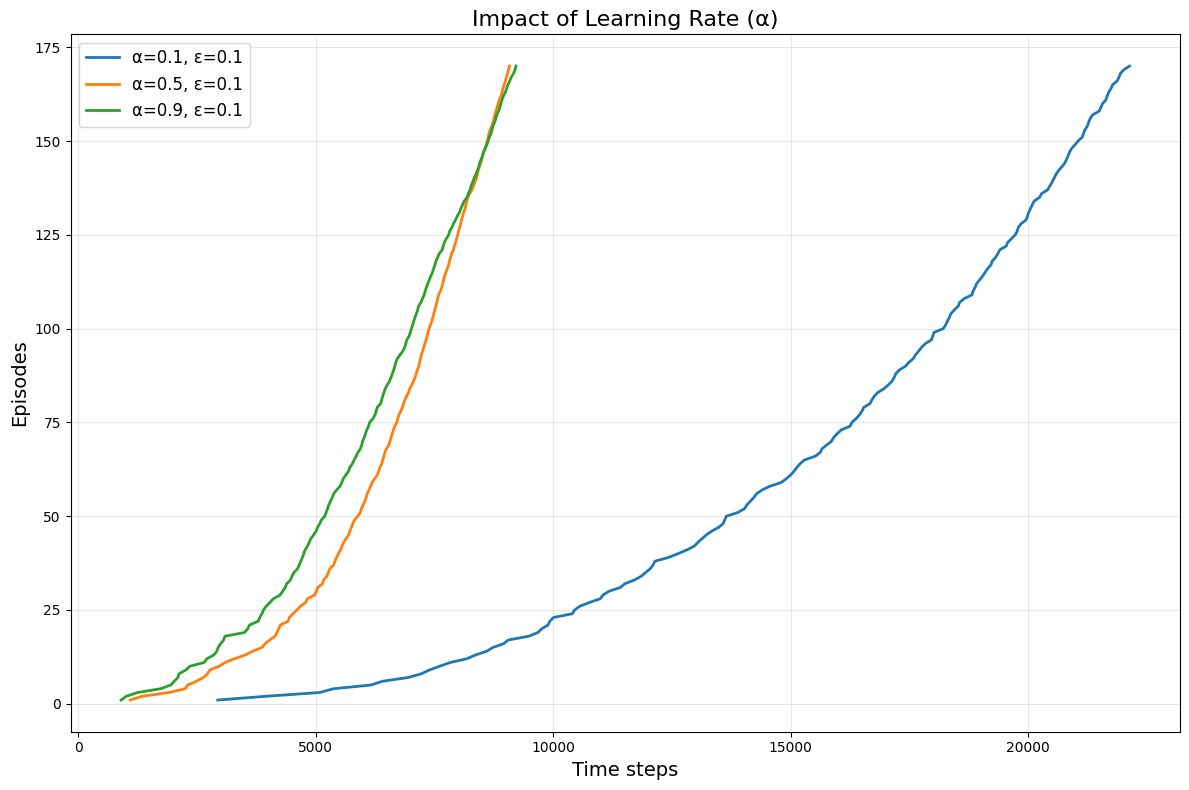

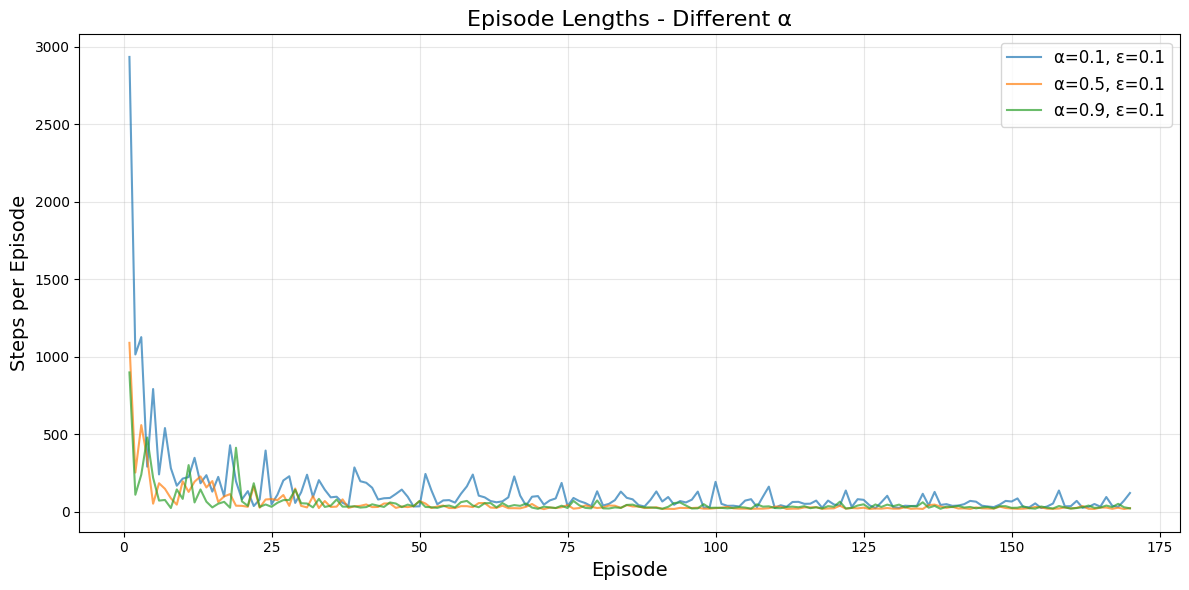


### TEST 3: Compare Different Exploration Rates ###

Testing with α=0.5, ε=0.05
Episode 10/170 | Steps: 271 | Avg (last 10): 329.3 | Total steps: 3293
Episode 20/170 | Steps: 44 | Avg (last 10): 92.3 | Total steps: 4216
Episode 30/170 | Steps: 89 | Avg (last 10): 55.3 | Total steps: 4769
Episode 40/170 | Steps: 30 | Avg (last 10): 56.1 | Total steps: 5330
Episode 50/170 | Steps: 29 | Avg (last 10): 35.6 | Total steps: 5686
Episode 60/170 | Steps: 33 | Avg (last 10): 36.1 | Total steps: 6047
Episode 70/170 | Steps: 22 | Avg (last 10): 30.4 | Total steps: 6351
Episode 80/170 | Steps: 32 | Avg (last 10): 26.4 | Total steps: 6615
Episode 90/170 | Steps: 22 | Avg (last 10): 23.6 | Total steps: 6851
Episode 100/170 | Steps: 34 | Avg (last 10): 24.6 | Total steps: 7097
Episode 110/170 | Steps: 23 | Avg (last 10): 21.8 | Total steps: 7315
Episode 120/170 | Steps: 20 | Avg (last 10): 18.8 | Total steps: 7503
Episode 130/170 | Steps: 18 | Avg (last 10): 24.3 | Total steps: 7746
Episode 140/170 

,0,1,2,3,4,5,6,7,8,9
0,←,→,→,→,→,→,→,→,→,↓
1,→,↑,→,→,→,→,→,→,←,↓
2,→,→,→,→,←,↑,↑,↓,↓,↓
3,→,→,→,↓,→,→,↑,+,→,↓
4,→,→,→,↓,→,↑,↑,↑,↓,↓
5,↓,→,↑,→,↑,↑,↑,↑,←,↓
6,←,→,→,↑,↑,↑,↑,↑,↑,←



Testing with α=0.5, ε=0.1
Episode 10/170 | Steps: 57 | Avg (last 10): 308.2 | Total steps: 3082
Episode 20/170 | Steps: 90 | Avg (last 10): 101.2 | Total steps: 4094
Episode 30/170 | Steps: 27 | Avg (last 10): 54.0 | Total steps: 4634
Episode 40/170 | Steps: 31 | Avg (last 10): 55.8 | Total steps: 5192
Episode 50/170 | Steps: 29 | Avg (last 10): 42.1 | Total steps: 5613
Episode 60/170 | Steps: 34 | Avg (last 10): 39.8 | Total steps: 6011
Episode 70/170 | Steps: 27 | Avg (last 10): 31.2 | Total steps: 6323
Episode 80/170 | Steps: 34 | Avg (last 10): 34.4 | Total steps: 6667
Episode 90/170 | Steps: 22 | Avg (last 10): 31.1 | Total steps: 6978
Episode 100/170 | Steps: 26 | Avg (last 10): 27.5 | Total steps: 7253
Episode 110/170 | Steps: 25 | Avg (last 10): 31.5 | Total steps: 7568
Episode 120/170 | Steps: 21 | Avg (last 10): 23.1 | Total steps: 7799
Episode 130/170 | Steps: 17 | Avg (last 10): 25.3 | Total steps: 8052
Episode 140/170 | Steps: 30 | Avg (last 10): 28.4 | Total steps: 8336


,0,1,2,3,4,5,6,7,8,9
0,→,↓,→,←,→,→,→,→,→,↓
1,↓,→,→,→,→,↓,→,↑,←,↓
2,→,→,↓,→,↑,→,↑,↓,↓,↓
3,→,↓,→,→,→,→,↑,+,→,↓
4,→,→,→,←,→,↑,↑,↑,→,↓
5,→,→,→,→,↑,↑,↑,↑,←,↓
6,↓,↓,→,↑,↑,↑,↑,↑,↑,←



Testing with α=0.5, ε=0.2
Episode 10/170 | Steps: 178 | Avg (last 10): 340.9 | Total steps: 3409
Episode 20/170 | Steps: 140 | Avg (last 10): 96.2 | Total steps: 4371
Episode 30/170 | Steps: 43 | Avg (last 10): 76.9 | Total steps: 5140
Episode 40/170 | Steps: 56 | Avg (last 10): 71.0 | Total steps: 5850
Episode 50/170 | Steps: 59 | Avg (last 10): 53.1 | Total steps: 6381
Episode 60/170 | Steps: 44 | Avg (last 10): 47.2 | Total steps: 6853
Episode 70/170 | Steps: 56 | Avg (last 10): 45.5 | Total steps: 7308
Episode 80/170 | Steps: 35 | Avg (last 10): 38.4 | Total steps: 7692
Episode 90/170 | Steps: 45 | Avg (last 10): 36.8 | Total steps: 8060
Episode 100/170 | Steps: 25 | Avg (last 10): 32.1 | Total steps: 8381
Episode 110/170 | Steps: 32 | Avg (last 10): 35.2 | Total steps: 8733
Episode 120/170 | Steps: 33 | Avg (last 10): 32.3 | Total steps: 9056
Episode 130/170 | Steps: 59 | Avg (last 10): 34.4 | Total steps: 9400
Episode 140/170 | Steps: 24 | Avg (last 10): 33.5 | Total steps: 9735

,0,1,2,3,4,5,6,7,8,9
0,↓,→,→,→,→,→,→,→,→,↓
1,→,→,↑,→,↑,↓,→,→,↑,↓
2,↑,↑,→,→,→,↑,↑,↓,↓,↓
3,↓,↑,↓,→,→,←,↑,+,→,↓
4,→,→,→,→,→,↑,↑,↑,↓,↓
5,↓,↓,→,→,↑,↑,↑,↑,←,↓
6,↓,←,↑,↑,↑,↑,↑,↑,↑,←


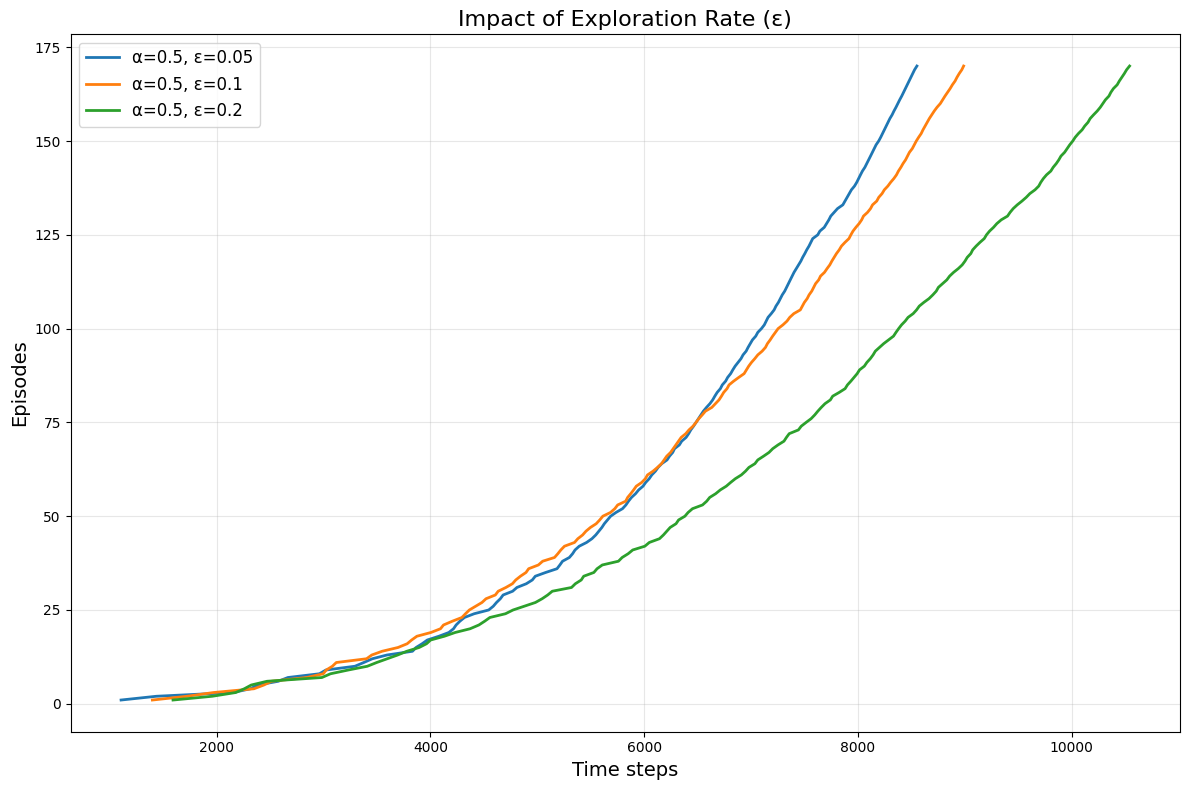

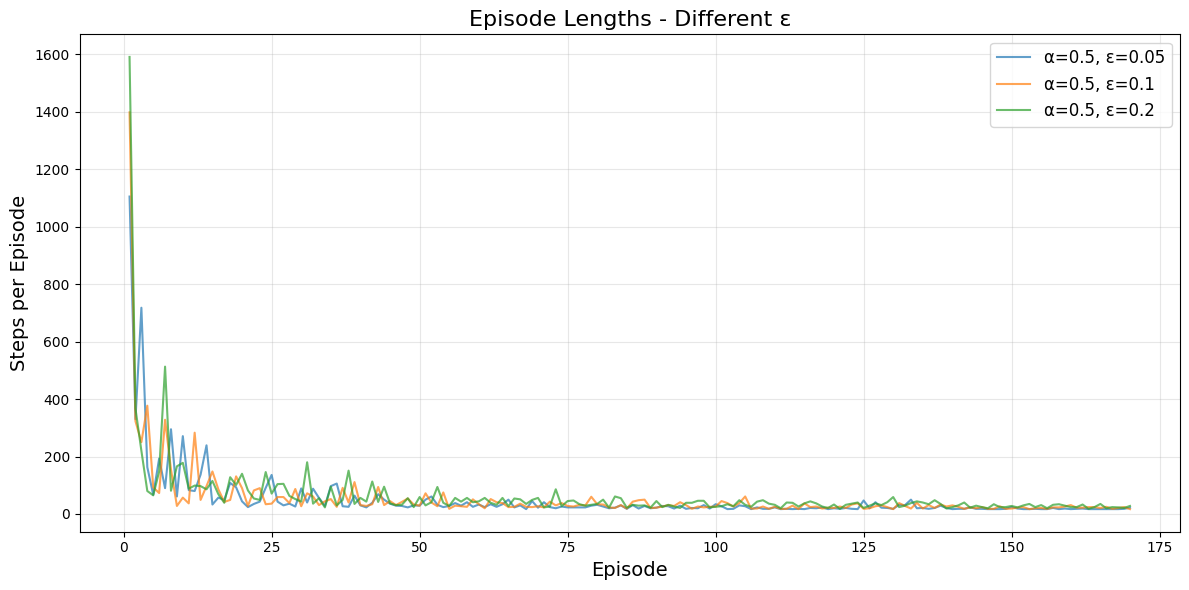


### TEST 4: Long-term Convergence ###

Testing with α=0.5, ε=0.1
Episode 10/500 | Steps: 134 | Avg (last 10): 297.2 | Total steps: 2972
Episode 20/500 | Steps: 62 | Avg (last 10): 118.9 | Total steps: 4161
Episode 30/500 | Steps: 105 | Avg (last 10): 62.8 | Total steps: 4789
Episode 40/500 | Steps: 40 | Avg (last 10): 49.5 | Total steps: 5284
Episode 50/500 | Steps: 48 | Avg (last 10): 38.0 | Total steps: 5664
Episode 60/500 | Steps: 21 | Avg (last 10): 31.5 | Total steps: 5979
Episode 70/500 | Steps: 29 | Avg (last 10): 36.0 | Total steps: 6339
Episode 80/500 | Steps: 33 | Avg (last 10): 34.3 | Total steps: 6682
Episode 90/500 | Steps: 31 | Avg (last 10): 28.8 | Total steps: 6970
Episode 100/500 | Steps: 33 | Avg (last 10): 27.9 | Total steps: 7249
Episode 110/500 | Steps: 21 | Avg (last 10): 24.9 | Total steps: 7498
Episode 120/500 | Steps: 18 | Avg (last 10): 23.9 | Total steps: 7737
Episode 130/500 | Steps: 21 | Avg (last 10): 22.5 | Total steps: 7962
Episode 140/500 | Steps: 26 |

,0,1,2,3,4,5,6,7,8,9
0,↑,→,→,→,→,→,→,→,→,↓
1,→,→,↑,→,→,→,→,↓,→,↓
2,→,→,↓,→,→,↑,↑,→,→,↓
3,→,→,→,→,↑,→,↑,+,→,↓
4,↓,→,→,→,→,↑,↑,↑,→,↓
5,←,→,↓,→,↑,↑,↑,↑,←,↓
6,←,→,→,↑,↑,↑,↑,↑,↑,←


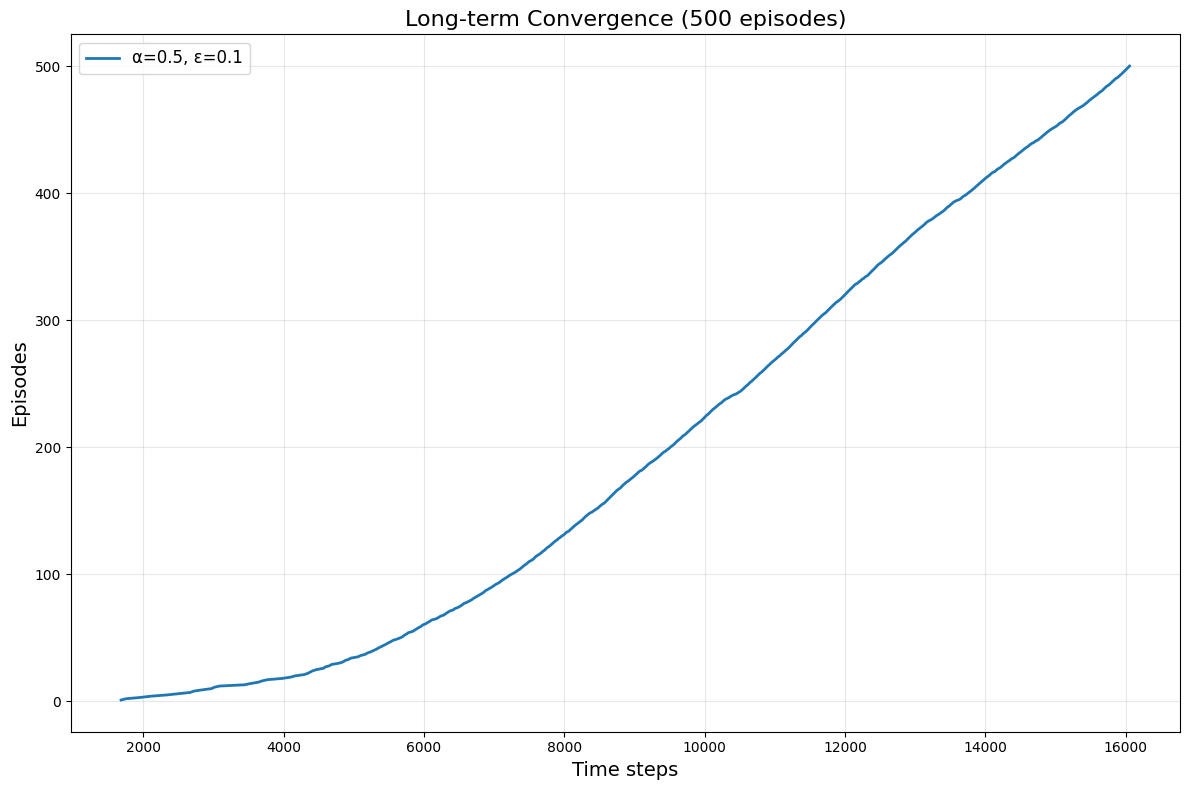

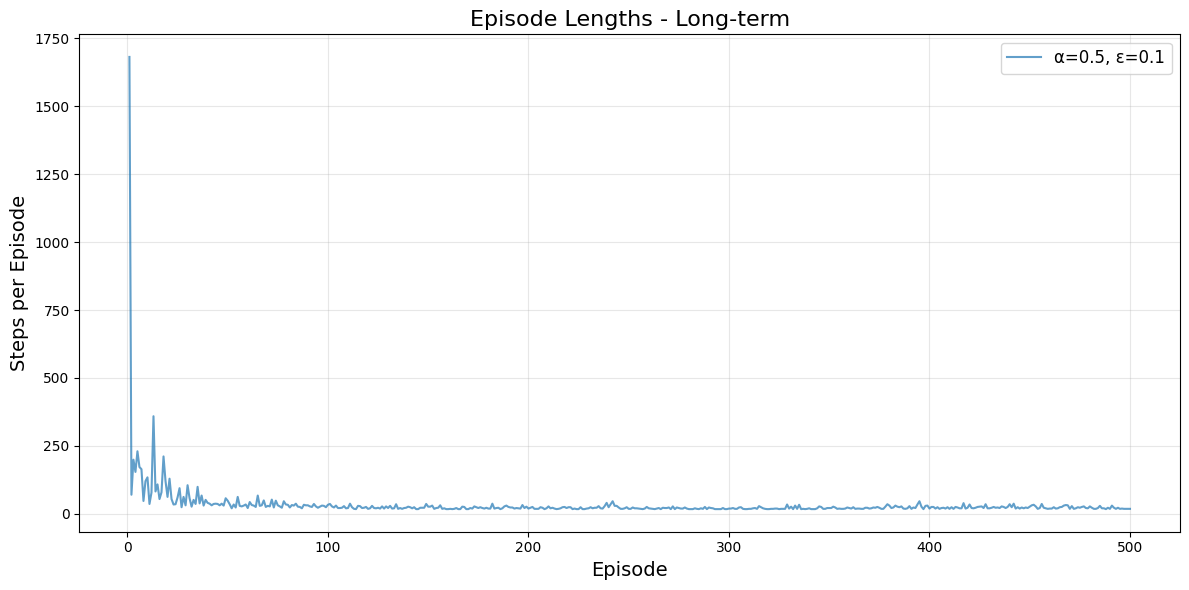


ALL TESTS COMPLETED


In [128]:
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

def test_sarsa_windy_gridworld(alpha_values=[0.5], epsilon_values=[0.1], max_episodes=200, max_steps_per_episode=10000):
    """
    Test SARSA on Windy Gridworld with different hyperparameters.
    Reproduces the plot from Example 6.5 in Sutton & Barto.
    
    Parameters:
    - alpha_values: list of learning rates to test
    - epsilon_values: list of exploration rates to test
    - max_episodes: maximum number of episodes to run
    - max_steps_per_episode: maximum steps per episode (safety limit)
    """
    
    # Set up the Windy Gridworld
    winds = {
        0: 0, 1: 0, 2: 0, 3: 1, 4: 1,
        5: 1, 6: 2, 7: 2, 8: 1, 9: 0
    }
    
    results = {}
    
    for alpha in alpha_values:
        for epsilon in epsilon_values:
            print(f"\n{'='*60}")
            print(f"Testing with α={alpha}, ε={epsilon}")
            print(f"{'='*60}")
            
            # Create fresh world
            windy_gridworld = WindyWorld(10, 7, winds)
            windy_gridworld.add_terminal(7, 3, "+")
            
            # Initialize Q-table
            Q_sarsa = np.full((windy_gridworld.width, windy_gridworld.height, len(ACTIONS)), 0.0)
            
            # Policy (epsilon-greedy)
            def policy(state):
                if random.random() >= epsilon:
                    return np.argmax(Q_sarsa[*state, :])
                else:
                    return random.randint(0, len(ACTIONS) - 1)
            
            # Track metrics
            episode_lengths = []
            cumulative_steps = []
            total_steps = 0
            start_time = time.time()
            
            # Training loop
            for episode in range(max_episodes):
                current_state = (0, 3)  # Start position from the example
                action_idx = policy(current_state)
                steps = 0
                
                # Episode loop
                while not windy_gridworld.is_terminal(*current_state) and steps < max_steps_per_episode:
                    # Take action
                    next_state = windy_gridworld.get_next_state(current_state, ACTIONS[action_idx])
                    reward = -1  # Constant reward of -1 as per example
                    
                    # Choose next action
                    next_action_idx = policy(next_state)
                    
                    # SARSA update
                    Q_current = Q_sarsa[*current_state, action_idx]
                    Q_next = Q_sarsa[*next_state, next_action_idx]
                    Q_sarsa[*current_state, action_idx] += alpha * (reward + Q_next - Q_current)
                    
                    # Move to next state
                    current_state = next_state
                    action_idx = next_action_idx
                    steps += 1
                    total_steps += 1
                
                episode_lengths.append(steps)
                cumulative_steps.append(total_steps)
                
                # Print progress
                if (episode + 1) % 10 == 0:
                    avg_length = np.mean(episode_lengths[-10:])
                    print(f"Episode {episode + 1}/{max_episodes} | "
                          f"Steps: {steps} | "
                          f"Avg (last 10): {avg_length:.1f} | "
                          f"Total steps: {total_steps}")
            
            elapsed_time = time.time() - start_time
            
            # Store results
            key = f"α={alpha}, ε={epsilon}"
            results[key] = {
                'episode_lengths': episode_lengths,
                'cumulative_steps': cumulative_steps,
                'Q': Q_sarsa.copy(),
                'time': elapsed_time
            }
            
            # Summary
            print(f"\n{'='*60}")
            print(f"Summary for α={alpha}, ε={epsilon}:")
            print(f"  Total episodes: {len(episode_lengths)}")
            print(f"  Total time steps: {total_steps}")
            print(f"  Training time: {elapsed_time:.2f}s")
            print(f"  Final avg episode length (last 10): {np.mean(episode_lengths[-10:]):.1f}")
            print(f"  Min episode length: {min(episode_lengths)}")
            print(f"{'='*60}\n")
            
            # Visualize learned policy
            print(f"Learned policy for α={alpha}, ε={epsilon}:")
            q_visualizer(windy_gridworld, Q_sarsa)
    
    return results


def plot_learning_curve(results, title="SARSA on Windy Gridworld"):
    """
    Plot the learning curve similar to Figure 6.3 in Sutton & Barto.
    Shows episodes vs time steps.
    """
    plt.figure(figsize=(12, 8))
    
    for key, data in results.items():
        cumulative_steps = data['cumulative_steps']
        episodes = list(range(1, len(cumulative_steps) + 1))
        plt.plot(cumulative_steps, episodes, label=key, linewidth=2)
    
    plt.xlabel('Time steps', fontsize=14)
    plt.ylabel('Episodes', fontsize=14)
    plt.title(title, fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_episode_lengths(results, title="Episode Length Over Time"):
    """
    Plot episode lengths over time to see convergence.
    """
    plt.figure(figsize=(12, 6))
    
    for key, data in results.items():
        episode_lengths = data['episode_lengths']
        episodes = list(range(1, len(episode_lengths) + 1))
        plt.plot(episodes, episode_lengths, label=key, alpha=0.7)
    
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Steps per Episode', fontsize=14)
    plt.title(title, fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


def analyze_optimal_path(windy_gridworld, Q):
    """
    Show the optimal path learned by the agent.
    """
    print("\n" + "="*60)
    print("OPTIMAL PATH ANALYSIS")
    print("="*60)
    
    current_state = (0, 3)
    path = [current_state]
    steps = 0
    max_steps = 100
    
    print(f"Starting from: {current_state}")
    print(f"Goal: (7, 3)")
    print("\nPath:")
    
    while not windy_gridworld.is_terminal(*current_state) and steps < max_steps:
        # Greedy action
        action_idx = np.argmax(Q[*current_state, :])
        action = ACTIONS[action_idx]
        
        # Take action
        next_state = windy_gridworld.get_next_state(current_state, action)
        path.append(next_state)
        
        print(f"  Step {steps + 1}: {current_state} --{action}--> {next_state}")
        
        current_state = next_state
        steps += 1
    
    print(f"\nTotal steps in optimal path: {steps}")
    print(f"Path coordinates: {path}")
    print("="*60 + "\n")
    
    return path


# Run the tests
print("SARSA WINDY GRIDWORLD TEST SUITE")
print("="*60)

# Test 1: Reproduce the example from the book
print("\n### TEST 1: Reproduce Example 6.5 ###")
results_book = test_sarsa_windy_gridworld(
    alpha_values=[0.5],
    epsilon_values=[0.1],
    max_episodes=170,
    max_steps_per_episode=10000
)

plot_learning_curve(results_book, "Windy Gridworld - Example 6.5 Reproduction")
plot_episode_lengths(results_book, "Episode Lengths - Example 6.5")

# Analyze the optimal path
key = "α=0.5, ε=0.1"
optimal_path = analyze_optimal_path(
    WindyWorld(10, 7, {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 1, 9: 0}),
    results_book[key]['Q']
)

# Test 2: Compare different learning rates
print("\n### TEST 2: Compare Different Learning Rates ###")
results_alpha = test_sarsa_windy_gridworld(
    alpha_values=[0.1, 0.5, 0.9],
    epsilon_values=[0.1],
    max_episodes=170,
    max_steps_per_episode=10000
)

plot_learning_curve(results_alpha, "Impact of Learning Rate (α)")
plot_episode_lengths(results_alpha, "Episode Lengths - Different α")

# Test 3: Compare different exploration rates
print("\n### TEST 3: Compare Different Exploration Rates ###")
results_epsilon = test_sarsa_windy_gridworld(
    alpha_values=[0.5],
    epsilon_values=[0.05, 0.1, 0.2],
    max_episodes=170,
    max_steps_per_episode=10000
)

plot_learning_curve(results_epsilon, "Impact of Exploration Rate (ε)")
plot_episode_lengths(results_epsilon, "Episode Lengths - Different ε")

# Test 4: Convergence test (longer training)
print("\n### TEST 4: Long-term Convergence ###")
results_long = test_sarsa_windy_gridworld(
    alpha_values=[0.5],
    epsilon_values=[0.1],
    max_episodes=500,
    max_steps_per_episode=10000
)

plot_learning_curve(results_long, "Long-term Convergence (500 episodes)")
plot_episode_lengths(results_long, "Episode Lengths - Long-term")

print("\n" + "="*60)
print("ALL TESTS COMPLETED")
print("="*60)

Starting convergence speed analysis...
This will test different learning rates and exploration rates

TEST 1: IMPACT OF LEARNING RATE (α) ON CONVERGENCE SPEED

Testing α=0.1, ε=0.1
  ✗ Did not converge within 300 episodes

Testing α=0.3, ε=0.1
  ✗ Did not converge within 300 episodes

Testing α=0.5, ε=0.1
  ✗ Did not converge within 300 episodes

Testing α=0.7, ε=0.1
  ✗ Did not converge within 300 episodes

Testing α=0.9, ε=0.1
  ✗ Did not converge within 300 episodes

TEST 2: IMPACT OF EXPLORATION RATE (ε) ON CONVERGENCE SPEED

Testing α=0.5, ε=0.05
  ✓ Converged at episode 137 with avg 18.1 steps/episode

Testing α=0.5, ε=0.1
  ✓ Converged at episode 205 with avg 19.5 steps/episode

Testing α=0.5, ε=0.15
  ✗ Did not converge within 300 episodes

Testing α=0.5, ε=0.2
  ✗ Did not converge within 300 episodes

Testing α=0.5, ε=0.3
  ✗ Did not converge within 300 episodes


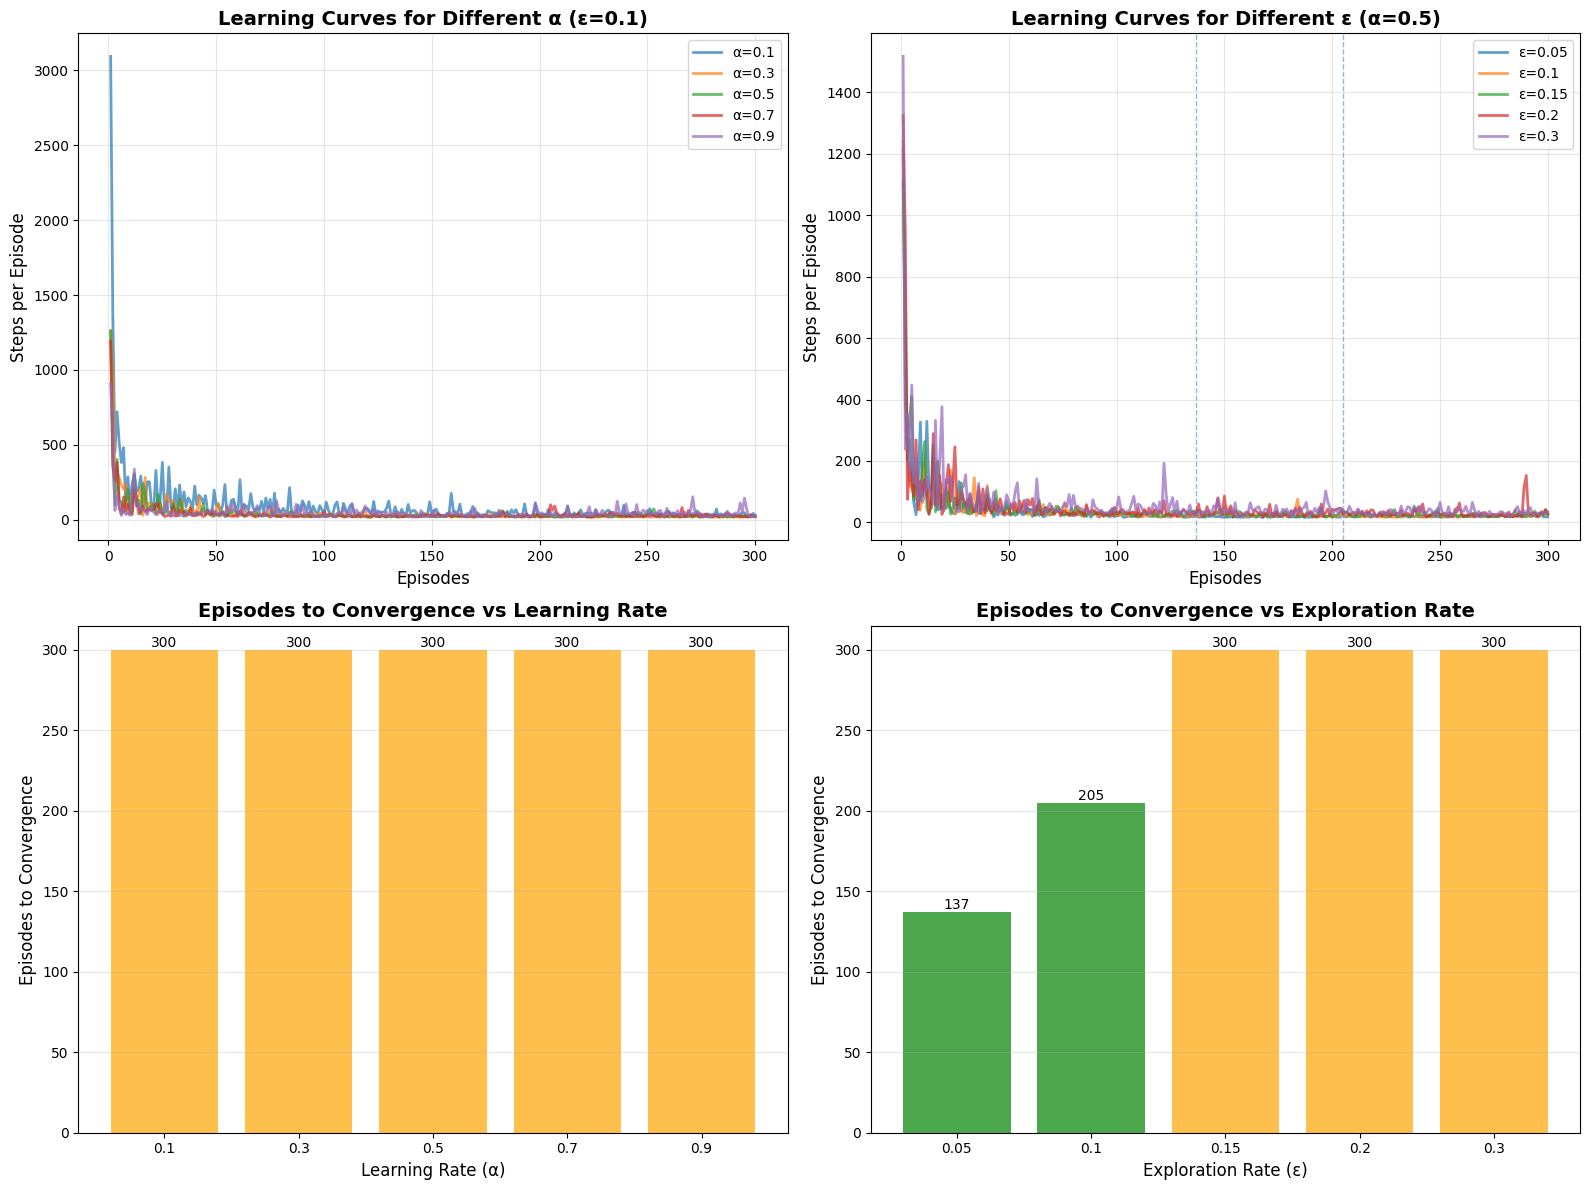


SUMMARY: EPISODES TO CONVERGENCE

Learning Rate (α)    Episodes to Converge      Final Avg Steps     
----------------------------------------------------------------------
α=0.1                300                       33.75
α=0.3                300                       19.10
α=0.5                300                       22.80
α=0.7                300                       26.85
α=0.9                300                       44.35

Exploration Rate (ε) Episodes to Converge      Final Avg Steps     
----------------------------------------------------------------------
ε=0.05               137                       20.60
ε=0.1                205                       22.75
ε=0.15               300                       26.45
ε=0.2                300                       37.55
ε=0.3                300                       31.75

BEST PARAMETERS
Fastest convergence with α=0.1 (converged at episode 300)
Fastest convergence with ε=0.05 (converged at episode 137)


In [129]:
import matplotlib.pyplot as plt
import time

def measure_convergence_speed(alpha_values=[0.1, 0.3, 0.5, 0.7, 0.9], 
                               epsilon_values=[0.05, 0.1, 0.15, 0.2], 
                               max_episodes=300,
                               convergence_window=20,
                               convergence_threshold=2.0):
    """
    Measure how many episodes it takes to converge to a good policy.
    
    Convergence is defined as: when the moving average of episode lengths 
    stabilizes (variance < threshold over convergence_window episodes)
    
    Parameters:
    - alpha_values: learning rates to test
    - epsilon_values: exploration rates to test
    - max_episodes: maximum episodes to run
    - convergence_window: number of episodes to check for stability
    - convergence_threshold: max std dev for convergence
    """
    
    winds = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 1, 9: 0}
    
    # Test 1: Different alpha values (fixed epsilon=0.1)
    print("="*70)
    print("TEST 1: IMPACT OF LEARNING RATE (α) ON CONVERGENCE SPEED")
    print("="*70)
    
    alpha_results = {}
    fixed_epsilon = 0.1
    
    for alpha in alpha_values:
        print(f"\nTesting α={alpha}, ε={fixed_epsilon}")
        
        windy_gridworld = WindyWorld(10, 7, winds)
        windy_gridworld.add_terminal(7, 3, "+")
        Q_sarsa = np.full((10, 7, len(ACTIONS)), 0.0)
        
        def policy(state):
            return np.argmax(Q_sarsa[*state, :]) if random.random() >= fixed_epsilon else random.randint(0, len(ACTIONS) - 1)
        
        episode_lengths = []
        converged_at = None
        
        for episode in range(max_episodes):
            current_state = (0, 3)
            action_idx = policy(current_state)
            steps = 0
            
            while not windy_gridworld.is_terminal(*current_state) and steps < 10000:
                next_state = windy_gridworld.get_next_state(current_state, ACTIONS[action_idx])
                reward = -1
                next_action_idx = policy(next_state)
                
                Q_current = Q_sarsa[*current_state, action_idx]
                Q_next = Q_sarsa[*next_state, next_action_idx]
                Q_sarsa[*current_state, action_idx] += alpha * (reward + Q_next - Q_current)
                
                current_state = next_state
                action_idx = next_action_idx
                steps += 1
            
            episode_lengths.append(steps)
            
            # Check for convergence
            if episode >= convergence_window and converged_at is None:
                recent = episode_lengths[-convergence_window:]
                if np.std(recent) < convergence_threshold:
                    converged_at = episode - convergence_window + 1
                    avg_steps = np.mean(recent)
                    print(f"  ✓ Converged at episode {converged_at} with avg {avg_steps:.1f} steps/episode")
        
        if converged_at is None:
            converged_at = max_episodes
            print(f"  ✗ Did not converge within {max_episodes} episodes")
        
        alpha_results[alpha] = {
            'episode_lengths': episode_lengths,
            'converged_at': converged_at,
            'final_avg': np.mean(episode_lengths[-20:])
        }
    
    # Test 2: Different epsilon values (fixed alpha=0.5)
    print("\n" + "="*70)
    print("TEST 2: IMPACT OF EXPLORATION RATE (ε) ON CONVERGENCE SPEED")
    print("="*70)
    
    epsilon_results = {}
    fixed_alpha = 0.5
    
    for epsilon in epsilon_values:
        print(f"\nTesting α={fixed_alpha}, ε={epsilon}")
        
        windy_gridworld = WindyWorld(10, 7, winds)
        windy_gridworld.add_terminal(7, 3, "+")
        Q_sarsa = np.full((10, 7, len(ACTIONS)), 0.0)
        
        def policy(state):
            return np.argmax(Q_sarsa[*state, :]) if random.random() >= epsilon else random.randint(0, len(ACTIONS) - 1)
        
        episode_lengths = []
        converged_at = None
        
        for episode in range(max_episodes):
            current_state = (0, 3)
            action_idx = policy(current_state)
            steps = 0
            
            while not windy_gridworld.is_terminal(*current_state) and steps < 10000:
                next_state = windy_gridworld.get_next_state(current_state, ACTIONS[action_idx])
                reward = -1
                next_action_idx = policy(next_state)
                
                Q_current = Q_sarsa[*current_state, action_idx]
                Q_next = Q_sarsa[*next_state, next_action_idx]
                Q_sarsa[*current_state, action_idx] += fixed_alpha * (reward + Q_next - Q_current)
                
                current_state = next_state
                action_idx = next_action_idx
                steps += 1
            
            episode_lengths.append(steps)
            
            # Check for convergence
            if episode >= convergence_window and converged_at is None:
                recent = episode_lengths[-convergence_window:]
                if np.std(recent) < convergence_threshold:
                    converged_at = episode - convergence_window + 1
                    avg_steps = np.mean(recent)
                    print(f"  ✓ Converged at episode {converged_at} with avg {avg_steps:.1f} steps/episode")
        
        if converged_at is None:
            converged_at = max_episodes
            print(f"  ✗ Did not converge within {max_episodes} episodes")
        
        epsilon_results[epsilon] = {
            'episode_lengths': episode_lengths,
            'converged_at': converged_at,
            'final_avg': np.mean(episode_lengths[-20:])
        }
    
    return alpha_results, epsilon_results


def plot_convergence_analysis(alpha_results, epsilon_results):
    """
    Create comprehensive plots showing convergence behavior
    """
    
    # Create figure with 2x2 subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Episode lengths over time for different alphas
    ax1.set_title('Learning Curves for Different α (ε=0.1)', fontsize=14, fontweight='bold')
    for alpha, data in alpha_results.items():
        episodes = range(1, len(data['episode_lengths']) + 1)
        ax1.plot(episodes, data['episode_lengths'], label=f'α={alpha}', alpha=0.7, linewidth=2)
        if data['converged_at'] < len(data['episode_lengths']):
            ax1.axvline(x=data['converged_at'], linestyle='--', alpha=0.5, linewidth=1)
    ax1.set_xlabel('Episodes', fontsize=12)
    ax1.set_ylabel('Steps per Episode', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Episode lengths over time for different epsilons
    ax2.set_title('Learning Curves for Different ε (α=0.5)', fontsize=14, fontweight='bold')
    for epsilon, data in epsilon_results.items():
        episodes = range(1, len(data['episode_lengths']) + 1)
        ax2.plot(episodes, data['episode_lengths'], label=f'ε={epsilon}', alpha=0.7, linewidth=2)
        if data['converged_at'] < len(data['episode_lengths']):
            ax2.axvline(x=data['converged_at'], linestyle='--', alpha=0.5, linewidth=1)
    ax2.set_xlabel('Episodes', fontsize=12)
    ax2.set_ylabel('Steps per Episode', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Bar chart - Episodes to convergence for different alphas
    ax3.set_title('Episodes to Convergence vs Learning Rate', fontsize=14, fontweight='bold')
    alphas = list(alpha_results.keys())
    convergence_episodes = [alpha_results[a]['converged_at'] for a in alphas]
    colors = ['green' if ce < 300 else 'orange' for ce in convergence_episodes]
    bars = ax3.bar(range(len(alphas)), convergence_episodes, color=colors, alpha=0.7)
    ax3.set_xticks(range(len(alphas)))
    ax3.set_xticklabels([f'{a}' for a in alphas])
    ax3.set_xlabel('Learning Rate (α)', fontsize=12)
    ax3.set_ylabel('Episodes to Convergence', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, convergence_episodes)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val)}', ha='center', va='bottom', fontsize=10)
    
    # Plot 4: Bar chart - Episodes to convergence for different epsilons
    ax4.set_title('Episodes to Convergence vs Exploration Rate', fontsize=14, fontweight='bold')
    epsilons = list(epsilon_results.keys())
    convergence_episodes = [epsilon_results[e]['converged_at'] for e in epsilons]
    colors = ['green' if ce < 300 else 'orange' for ce in convergence_episodes]
    bars = ax4.bar(range(len(epsilons)), convergence_episodes, color=colors, alpha=0.7)
    ax4.set_xticks(range(len(epsilons)))
    ax4.set_xticklabels([f'{e}' for e in epsilons])
    ax4.set_xlabel('Exploration Rate (ε)', fontsize=12)
    ax4.set_ylabel('Episodes to Convergence', fontsize=12)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, convergence_episodes)):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val)}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n" + "="*70)
    print("SUMMARY: EPISODES TO CONVERGENCE")
    print("="*70)
    
    print(f"\n{'Learning Rate (α)':<20} {'Episodes to Converge':<25} {'Final Avg Steps':<20}")
    print("-" * 70)
    for alpha, data in alpha_results.items():
        print(f"α={alpha:<18} {data['converged_at']:<25} {data['final_avg']:.2f}")
    
    print(f"\n{'Exploration Rate (ε)':<20} {'Episodes to Converge':<25} {'Final Avg Steps':<20}")
    print("-" * 70)
    for epsilon, data in epsilon_results.items():
        print(f"ε={epsilon:<18} {data['converged_at']:<25} {data['final_avg']:.2f}")
    
    # Find best parameters
    best_alpha = min(alpha_results.keys(), key=lambda a: alpha_results[a]['converged_at'])
    best_epsilon = min(epsilon_results.keys(), key=lambda e: epsilon_results[e]['converged_at'])
    
    print("\n" + "="*70)
    print("BEST PARAMETERS")
    print("="*70)
    print(f"Fastest convergence with α={best_alpha} (converged at episode {alpha_results[best_alpha]['converged_at']})")
    print(f"Fastest convergence with ε={best_epsilon} (converged at episode {epsilon_results[best_epsilon]['converged_at']})")
    print("="*70)


# Run the convergence analysis
print("Starting convergence speed analysis...")
print("This will test different learning rates and exploration rates\n")

alpha_results, epsilon_results = measure_convergence_speed(
    alpha_values=[0.1, 0.3, 0.5, 0.7, 0.9],
    epsilon_values=[0.05, 0.1, 0.15, 0.2, 0.3],
    max_episodes=300,
    convergence_window=20,
    convergence_threshold=2.0
)

# Plot the results
plot_convergence_analysis(alpha_results, epsilon_results)